# Evaluación de la calidad de los datos de MetroPT-3

## Objetivo

El objetivo de este notebook es evaluar sistemáticamente la calidad del dataset MetroPT-3 antes de implementar las transformaciones del pipeline.

Se analizarán:

- la presencia de columnas obligatorias;
- los valores nulos;
- los registros duplicados;
- la validez de las señales binarias;
- el orden cronológico;
- los timestamps duplicados;
- la continuidad temporal;
- los valores fuera de los rangos observados.

In [34]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/MetroPT3(AirCompressor).csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["timestamp"]
)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Timestamp: {df['timestamp'].dtype}")

Filas: 1,516,948
Columnas: 17
Timestamp: datetime64[us]


In [35]:
parse_dates=["timestamp"]

# 1. Validación del esquema

En esta sección se comprueba que el dataset contiene todas las columnas esperadas y que no existen columnas desconocidas.

Esta validación permite detectar cambios en la estructura del fichero antes de ejecutar el resto del pipeline.

In [36]:
EXPECTED_COLUMNS = {
    "Unnamed: 0",
    "timestamp",
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Motor_current",
    "COMP",
    "DV_eletric",
    "Towers",
    "MPG",
    "LPS",
    "Pressure_switch",
    "Oil_level",
    "Caudal_impulses",
}

actual_columns = set(df.columns)

missing_columns = EXPECTED_COLUMNS - actual_columns
unexpected_columns = actual_columns - EXPECTED_COLUMNS

print("Columnas esperadas:", len(EXPECTED_COLUMNS))
print("Columnas encontradas:", len(actual_columns))
print("Columnas ausentes:", missing_columns)
print("Columnas inesperadas:", unexpected_columns)

Columnas esperadas: 17
Columnas encontradas: 17
Columnas ausentes: set()
Columnas inesperadas: set()


In [37]:
schema_check = pd.DataFrame({
    "Comprobación": [
        "Número de columnas",
        "Columnas obligatorias presentes",
        "Columnas inesperadas"
    ],
    "Resultado": [
        len(actual_columns) == len(EXPECTED_COLUMNS),
        len(missing_columns) == 0,
        len(unexpected_columns) == 0
    ],
    "Detalle": [
        f"{len(actual_columns)} de {len(EXPECTED_COLUMNS)}",
        sorted(missing_columns) if missing_columns else "Ninguna ausente",
        sorted(unexpected_columns) if unexpected_columns else "Ninguna"
    ]
})

schema_check

,Comprobación,Resultado,Detalle
0,Número de columnas,True,17 de 17
1,Columnas obligatorias presentes,True,Ninguna ausente
2,Columnas inesperadas,True,Ninguna


## Interpretación

El dataset contiene las 17 columnas esperadas y no presenta columnas ausentes ni adicionales. Por tanto, su estructura es compatible con el esquema definido para el proyecto.

Esta comprobación se incorporará posteriormente al módulo de validación del pipeline para evitar que se procesen ficheros con una estructura incorrecta.

# 2. Validación de tipos de datos

En esta sección se comprueba que las columnas presentan tipos compatibles con su significado:

- `timestamp` debe ser una variable temporal;
- `Unnamed: 0` debe ser numérica entera;
- los sensores analógicos deben ser numéricos;
- las señales digitales deben ser numéricas antes de validar su dominio.

In [38]:
ANALOG_COLUMNS = [
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Motor_current",
]

BINARY_COLUMNS = [
    "COMP",
    "DV_eletric",
    "Towers",
    "MPG",
    "LPS",
    "Pressure_switch",
    "Oil_level",
    "Caudal_impulses",
]

In [39]:
type_checks = {
    "timestamp_datetime": pd.api.types.is_datetime64_any_dtype(
        df["timestamp"]
    ),
    "index_integer": pd.api.types.is_integer_dtype(
        df["Unnamed: 0"]
    ),
    "analog_numeric": all(
        pd.api.types.is_numeric_dtype(df[column])
        for column in ANALOG_COLUMNS
    ),
    "binary_numeric": all(
        pd.api.types.is_numeric_dtype(df[column])
        for column in BINARY_COLUMNS
    ),
}

type_check_report = pd.DataFrame(
    {
        "Comprobación": type_checks.keys(),
        "Resultado": type_checks.values(),
    }
)

type_check_report

,Comprobación,Resultado
0,timestamp_datetime,True
1,index_integer,True
2,analog_numeric,True
3,binary_numeric,True


In [40]:
dtype_report = pd.DataFrame(
    {
        "Columna": df.columns,
        "Tipo detectado": df.dtypes.astype(str).values,
    }
)

dtype_report

,Columna,Tipo detectado
0,Unnamed: 0,int64
1,timestamp,datetime64[us]
2,TP2,float64
3,TP3,float64
4,H1,float64
5,DV_pressure,float64
6,Reservoirs,float64
7,Oil_temperature,float64
8,Motor_current,float64
9,COMP,float64


## Interpretación

La columna `timestamp` ha sido convertida correctamente a un tipo temporal durante la carga del fichero.

La columna `Unnamed: 0` presenta un tipo entero, mientras que las variables analógicas y digitales son numéricas.

Aunque las señales digitales están almacenadas como `float64`, sus tipos son compatibles con la validación inicial. Posteriormente se comprobará que únicamente contienen los valores 0 y 1 y se estudiará su conversión a un tipo más eficiente.

# 3. Validación de valores nulos

En esta sección se comprueba la presencia de valores ausentes en cada columna del dataset.

La detección de valores nulos es necesaria porque su existencia puede afectar a las transformaciones posteriores, al cálculo de variables derivadas y al funcionamiento de los modelos analíticos.

In [41]:
null_report = pd.DataFrame(
    {
        "Columna": df.columns,
        "Valores nulos": df.isna().sum().values,
        "Porcentaje nulos": (
            df.isna().mean().mul(100).round(4).values
        ),
    }
)

null_report

,Columna,Valores nulos,Porcentaje nulos
0,Unnamed: 0,0,0.0
1,timestamp,0,0.0
2,TP2,0,0.0
3,TP3,0,0.0
4,H1,0,0.0
5,DV_pressure,0,0.0
6,Reservoirs,0,0.0
7,Oil_temperature,0,0.0
8,Motor_current,0,0.0
9,COMP,0,0.0


In [42]:


total_nulls = int(df.isna().sum().sum())
columns_with_nulls = int((df.isna().sum() > 0).sum())

null_summary = pd.DataFrame(
    {
        "Métrica": [
            "Total de valores nulos",
            "Columnas con valores nulos",
            "Dataset sin valores nulos",
        ],
        "Resultado": [
            total_nulls,
            columns_with_nulls,
            total_nulls == 0,
        ],
    }
)

null_summary

,Métrica,Resultado
0,Total de valores nulos,0
1,Columnas con valores nulos,0
2,Dataset sin valores nulos,True


## Interpretación

No se detectan valores nulos en ninguna de las columnas del dataset MetroPT-3.

Por tanto, no es necesario aplicar técnicas de imputación o eliminación de registros en esta fase. Sin embargo, la comprobación de valores nulos se mantendrá como una regla del pipeline para detectar posibles problemas en futuros ficheros de entrada.

# 4. Validación de registros duplicados

En esta sección se comprueba la existencia de filas completamente duplicadas y de marcas temporales repetidas.

Una fila duplicada representa una repetición exacta de todos los valores del registro. En cambio, un timestamp duplicado indica que existen varias observaciones asociadas al mismo instante, aunque sus mediciones puedan ser diferentes.

In [43]:
#Filas completamente duplicadas

duplicate_rows = int(df.duplicated().sum())

duplicate_rows_report = pd.DataFrame(
    {
        "Comprobación": [
            "Filas completamente duplicadas",
            "Dataset sin filas duplicadas",
        ],
        "Resultado": [
            duplicate_rows,
            duplicate_rows == 0,
        ],
    }
)

duplicate_rows_report

,Comprobación,Resultado
0,Filas completamente duplicadas,0
1,Dataset sin filas duplicadas,True


In [44]:
#Timestamps duplicados

duplicate_timestamps = int(
    df["timestamp"].duplicated().sum()
)

duplicate_timestamp_report = pd.DataFrame(
    {
        "Comprobación": [
            "Timestamps duplicados",
            "Serie temporal sin timestamps duplicados",
        ],
        "Resultado": [
            duplicate_timestamps,
            duplicate_timestamps == 0,
        ],
    }
)

duplicate_timestamp_report


,Comprobación,Resultado
0,Timestamps duplicados,0
1,Serie temporal sin timestamps duplicados,True


In [45]:
#Mostrar los registros afectados

if duplicate_timestamps > 0:
    duplicated_timestamp_rows = (
        df[df["timestamp"].duplicated(keep=False)]
        .sort_values("timestamp")
    )

    display(duplicated_timestamp_rows.head(20))
else:
    print("No se detectan timestamps duplicados.")

No se detectan timestamps duplicados.


In [46]:
#Resumen conjunto

duplicate_summary = pd.DataFrame(
    {
        "Tipo de duplicado": [
            "Filas completas",
            "Timestamps",
        ],
        "Cantidad": [
            duplicate_rows,
            duplicate_timestamps,
        ],
        "Validación superada": [
            duplicate_rows == 0,
            duplicate_timestamps == 0,
        ],
    }
)

duplicate_summary

,Tipo de duplicado,Cantidad,Validación superada
0,Filas completas,0,True
1,Timestamps,0,True


## Interpretación

No se detectan filas completamente duplicadas ni timestamps repetidos en el dataset.

Cada observación está asociada a una marca temporal única, lo que evita ambigüedades en el orden de la serie y facilita el análisis de la continuidad temporal.

Estas comprobaciones se incorporarán al módulo de validación del pipeline para impedir que registros repetidos alteren las estadísticas, las transformaciones o el análisis de anomalías.

# 5. Validación del orden cronológico

En esta sección se comprueba que los registros estén ordenados de forma ascendente según la columna `timestamp`.

Un orden temporal incorrecto puede afectar al cálculo de diferencias, ventanas temporales, variables derivadas y modelos de detección de anomalías.

In [47]:
#Comprobación general de la serie temporal

is_chronologically_sorted = df["timestamp"].is_monotonic_increasing

chronological_order_report = pd.DataFrame(
    {
        "Comprobación": [
            "Serie ordenada cronológicamente",
        ],
        "Resultado": [
            is_chronologically_sorted,
        ],
    }
)

chronological_order_report

,Comprobación,Resultado
0,Serie ordenada cronológicamente,True


In [48]:
#Detección de retrocesos temporales

timestamp_differences = df["timestamp"].diff()

temporal_reversals = int(
    (timestamp_differences < pd.Timedelta(0)).sum()
)

temporal_reversal_report = pd.DataFrame(
    {
        "Comprobación": [
            "Retrocesos temporales detectados",
            "Serie sin retrocesos temporales",
        ],
        "Resultado": [
            temporal_reversals,
            temporal_reversals == 0,
        ],
    }
)

temporal_reversal_report

,Comprobación,Resultado
0,Retrocesos temporales detectados,0
1,Serie sin retrocesos temporales,True


In [49]:
#Inspección de los registros afectados

if temporal_reversals > 0:
    reversal_mask = timestamp_differences < pd.Timedelta(0)

    reversal_positions = df.index[reversal_mask]

    display(
        df.loc[
            sorted(
                set(reversal_positions.tolist())
                | set((reversal_positions - 1).tolist())
            )
        ].head(20)
    )
else:
    print("No se detectan retrocesos temporales.")

No se detectan retrocesos temporales.


## Interpretación

Los registros se encuentran ordenados cronológicamente de forma ascendente y no se detectan retrocesos temporales.

Por tanto, el orden actual del dataset permite calcular diferencias entre observaciones y construir ventanas temporales sin aplicar previamente una operación de ordenación.

Aun así, el pipeline incluirá esta comprobación para detectar posibles ficheros de entrada desordenados.

No ordenamos todavía el DataFrame con sort_values(), porque primero queremos comprobar la calidad real del fichero original, no corregir silenciosamente posibles errores.

# 6. Validación de variables binarias

En esta sección se comprueba que las señales digitales contengan exclusivamente los valores permitidos `0` y `1`.

La presencia de cualquier otro valor indicaría un problema de calidad, codificación o interpretación de los datos.

In [50]:
BINARY_COLUMNS = [
    "COMP",
    "DV_eletric",
    "Towers",
    "MPG",
    "LPS",
    "Pressure_switch",
    "Oil_level",
    "Caudal_impulses",
]

ALLOWED_BINARY_VALUES = {0, 1}

In [51]:
#Comprobacion del dominio de las columnas binarias

binary_domain_results = []

for column in BINARY_COLUMNS:
    observed_values = set(df[column].dropna().unique())
    invalid_values = observed_values - ALLOWED_BINARY_VALUES

    binary_domain_results.append(
        {
            "Columna": column,
            "Valores observados": sorted(observed_values),
            "Valores no válidos": sorted(invalid_values),
            "Validación superada": len(invalid_values) == 0,
        }
    )

binary_domain_report = pd.DataFrame(binary_domain_results)

binary_domain_report

,Columna,Valores observados,Valores no válidos,Validación superada
0,COMP,"[0.0, 1.0]",[],True
1,DV_eletric,"[0.0, 1.0]",[],True
2,Towers,"[0.0, 1.0]",[],True
3,MPG,"[0.0, 1.0]",[],True
4,LPS,"[0.0, 1.0]",[],True
5,Pressure_switch,"[0.0, 1.0]",[],True
6,Oil_level,"[0.0, 1.0]",[],True
7,Caudal_impulses,"[0.0, 1.0]",[],True


In [52]:
#Recuento de registros no válidos en columnas binarias

invalid_binary_counts = []

for column in BINARY_COLUMNS:
    invalid_mask = ~df[column].isin(ALLOWED_BINARY_VALUES)

    invalid_binary_counts.append(
        {
            "Columna": column,
            "Registros no válidos": int(invalid_mask.sum()),
            "Porcentaje no válido": round(
                invalid_mask.mean() * 100,
                6,
            ),
        }
    )

invalid_binary_report = pd.DataFrame(invalid_binary_counts)

invalid_binary_report

,Columna,Registros no válidos,Porcentaje no válido
0,COMP,0,0.0
1,DV_eletric,0,0.0
2,Towers,0,0.0
3,MPG,0,0.0
4,LPS,0,0.0
5,Pressure_switch,0,0.0
6,Oil_level,0,0.0
7,Caudal_impulses,0,0.0


In [53]:
#Resumen general

total_invalid_binary_values = int(
    invalid_binary_report["Registros no válidos"].sum()
)

binary_summary = pd.DataFrame(
    {
        "Métrica": [
            "Variables binarias evaluadas",
            "Total de registros con valores no válidos",
            "Dominio binario válido",
        ],
        "Resultado": [
            len(BINARY_COLUMNS),
            total_invalid_binary_values,
            total_invalid_binary_values == 0,
        ],
    }
)

binary_summary

,Métrica,Resultado
0,Variables binarias evaluadas,8
1,Total de registros con valores no válidos,0
2,Dominio binario válido,True


## Interpretación

Las ocho señales digitales contienen exclusivamente los valores `0` y `1`, por lo que su codificación es consistente con su naturaleza binaria.

No se detectan valores fuera del dominio esperado. En una etapa posterior de transformación, estas variables podrán convertirse desde `float64` a un tipo más eficiente, como `uint8` o `bool`, reduciendo el consumo de memoria y representando de forma más precisa su significado.

# 7. Validación de la continuidad temporal

En esta sección se analizan los intervalos entre observaciones consecutivas para identificar variaciones respecto al intervalo nominal de muestreo y posibles interrupciones en la adquisición de datos.

Según el análisis exploratorio, el intervalo más frecuente es de 10 segundos. No obstante, existen pequeñas variaciones y algunos huecos de mayor duración.

In [54]:
#Definir el intervalo nominal
 
EXPECTED_INTERVAL = pd.Timedelta(seconds=10)

time_intervals = df["timestamp"].diff().dropna()

#Resumen estadístico

temporal_interval_summary = pd.DataFrame(
    {
        "Métrica": [
            "Intervalo mínimo",
            "Intervalo mediano",
            "Intervalo medio",
            "Intervalo máximo",
            "Intervalo nominal",
        ],
        "Resultado": [
            time_intervals.min(),
            time_intervals.median(),
            time_intervals.mean(),
            time_intervals.max(),
            EXPECTED_INTERVAL,
        ],
    }
)

temporal_interval_summary

,Métrica,Resultado
0,Intervalo mínimo,0 days 00:00:08
1,Intervalo mediano,0 days 00:00:10
2,Intervalo medio,0 days 00:00:12.141221
3,Intervalo máximo,2 days 00:01:58
4,Intervalo nominal,0 days 00:00:10


In [55]:
#Distribución de los intervalos más frecuentes

interval_distribution = (
    time_intervals
    .value_counts()
    .rename_axis("Intervalo")
    .reset_index(name="Cantidad")
)

interval_distribution["Porcentaje"] = (
    interval_distribution["Cantidad"]
    .div(len(time_intervals))
    .mul(100)
    .round(6)
)

interval_distribution.head(15)

,Intervalo,Cantidad,Porcentaje
0,0 days 00:00:10,1337521,88.171901
1,0 days 00:00:09,128277,8.456261
2,0 days 00:00:12,38321,2.526192
3,0 days 00:00:13,7988,0.526584
4,0 days 00:00:11,4471,0.294737
5,0 days 00:00:21,10,0.000659
6,0 days 00:00:19,5,0.000330
7,0 days 00:00:22,4,0.000264
8,0 days 00:00:20,3,0.000198
9,0 days 00:00:17,3,0.000198


In [56]:
#Clasificación de los intervalos 
# Para este análisis vamos a distinguir:
# intervalos exactos de 10 segundos;
# pequeñas variaciones entre 8 y 13 segundos;
# huecos superiores a 13 segundos.


NORMAL_MIN_INTERVAL = pd.Timedelta(seconds=8)
NORMAL_MAX_INTERVAL = pd.Timedelta(seconds=13)

exact_intervals = time_intervals == EXPECTED_INTERVAL

small_variations = (
    time_intervals.between(
        NORMAL_MIN_INTERVAL,
        NORMAL_MAX_INTERVAL,
    )
    & ~exact_intervals
)

temporal_gaps = time_intervals > NORMAL_MAX_INTERVAL

In [57]:
#Informe de continuidad

temporal_continuity_report = pd.DataFrame(
    {
        "Clasificación": [
            "Intervalo exacto de 10 segundos",
            "Pequeñas variaciones entre 8 y 13 segundos",
            "Huecos superiores a 13 segundos",
        ],
        "Cantidad": [
            int(exact_intervals.sum()),
            int(small_variations.sum()),
            int(temporal_gaps.sum()),
        ],
        "Porcentaje": [
            round(exact_intervals.mean() * 100, 6),
            round(small_variations.mean() * 100, 6),
            round(temporal_gaps.mean() * 100, 6),
        ],
    }
)

temporal_continuity_report

,Clasificación,Cantidad,Porcentaje
0,Intervalo exacto de 10 segundos,1337521,88.171901
1,Pequeñas variaciones entre 8 y 13 segundos,179059,11.803906
2,Huecos superiores a 13 segundos,367,0.024193


In [59]:
# Diferencias temporales conservando el mismo índice que df
timestamp_differences = df["timestamp"].diff()

# Máscara con el mismo índice que el DataFrame
temporal_gap_mask = timestamp_differences > NORMAL_MAX_INTERVAL

gap_report = pd.DataFrame(
    {
        "Timestamp anterior": df["timestamp"].shift(1).loc[temporal_gap_mask],
        "Timestamp actual": df["timestamp"].loc[temporal_gap_mask],
        "Duración del hueco": timestamp_differences.loc[temporal_gap_mask],
    }
)

gap_report = (
    gap_report
    .sort_values("Duración del hueco", ascending=False)
    .reset_index(drop=True)
)

gap_report.head(20)

,Timestamp anterior,Timestamp actual,Duración del hueco
0,2020-04-25 01:10:51,2020-04-27 01:12:49,2 days 00:01:58
1,2020-06-27 10:53:07,2020-06-28 23:07:43,1 days 12:14:36
2,2020-02-28 23:57:08,2020-03-01 04:00:09,1 days 04:03:01
3,2020-08-04 07:42:28,2020-08-05 08:23:01,1 days 00:40:33
4,2020-05-24 00:39:23,2020-05-25 01:14:14,1 days 00:34:51
5,2020-07-07 15:24:51,2020-07-08 15:20:51,0 days 23:56:00
6,2020-08-22 19:11:44,2020-08-23 18:51:01,0 days 23:39:17
7,2020-05-10 00:31:17,2020-05-10 22:48:58,0 days 22:17:41
8,2020-06-07 14:19:39,2020-06-08 11:48:04,0 days 21:28:25
9,2020-04-01 13:15:40,2020-04-02 09:59:17,0 days 20:43:37


In [60]:
#Resumen de los huecos

temporal_gap_summary = pd.DataFrame(
    {
        "Métrica": [
            "Número de huecos detectados",
            "Mayor hueco temporal",
            "Huecos superiores a 1 minuto",
            "Huecos superiores a 5 minutos",
            "Huecos superiores a 1 hora",
        ],
        "Resultado": [
            int(temporal_gaps.sum()),
            time_intervals[temporal_gaps].max(),
            int((time_intervals > pd.Timedelta(minutes=1)).sum()),
            int((time_intervals > pd.Timedelta(minutes=5)).sum()),
            int((time_intervals > pd.Timedelta(hours=1)).sum()),
        ],
    }
)

temporal_gap_summary

,Métrica,Resultado
0,Número de huecos detectados,367
1,Mayor hueco temporal,2 days 00:01:58
2,Huecos superiores a 1 minuto,331
3,Huecos superiores a 5 minutos,275
4,Huecos superiores a 1 hora,160


## Interpretación

La serie presenta una frecuencia nominal de adquisición de aproximadamente 10 segundos, aunque no es completamente continua.

Se han detectado:

- **367 intervalos superiores a 13 segundos**;
- **331 intervalos superiores a un minuto**;
- **275 intervalos superiores a cinco minutos**;
- **160 intervalos superiores a una hora**;
- un intervalo máximo de **2 días, 1 minuto y 58 segundos**.

Estos resultados indican que existen interrupciones puntuales en la adquisición. Por ello, las etapas posteriores deberán evitar construir ventanas temporales que atraviesen huecos prolongados sin identificarlos previamente.

Los huecos no se corregirán ni interpolarán automáticamente, ya que hacerlo podría introducir mediciones artificiales. El pipeline los detectará y registrará como incidencias de calidad temporal.

# 8. Validación de las variables analógicas

En esta sección se examinan los sensores analógicos para detectar valores no numéricos, valores infinitos, variables constantes y rangos que requieran una revisión posterior.

La identificación estadística de valores extremos no implica necesariamente que sean errores, ya que pueden corresponder a cambios operativos o periodos próximos a una avería.

In [61]:
import numpy as np

ANALOG_COLUMNS = [
    "TP2",
    "TP3",
    "H1",
    "DV_pressure",
    "Reservoirs",
    "Oil_temperature",
    "Motor_current",
]

analog_quality_report = pd.DataFrame(
    {
        "Columna": ANALOG_COLUMNS,
        "Tipo": [str(df[column].dtype) for column in ANALOG_COLUMNS],
        "Valores únicos": [
            df[column].nunique(dropna=True)
            for column in ANALOG_COLUMNS
        ],
        "Mínimo": [
            df[column].min()
            for column in ANALOG_COLUMNS
        ],
        "Mediana": [
            df[column].median()
            for column in ANALOG_COLUMNS
        ],
        "Máximo": [
            df[column].max()
            for column in ANALOG_COLUMNS
        ],
        "Valores infinitos": [
            int(np.isinf(df[column]).sum())
            for column in ANALOG_COLUMNS
        ],
    }
)

analog_quality_report

,Columna,Tipo,Valores únicos,Mínimo,Mediana,Máximo,Valores infinitos
0,TP2,float64,5257,-0.032,-0.012,10.676,0
1,TP3,float64,3683,0.730,8.960,10.302,0
2,H1,float64,2665,-0.036,8.784,10.288,0
3,DV_pressure,float64,2257,-0.032,-0.020,9.844,0
4,Reservoirs,float64,3682,0.712,8.960,10.300,0
5,Oil_temperature,float64,2462,15.400,62.700,89.050,0
6,Motor_current,float64,1809,0.020,0.045,9.295,0


In [63]:
# Comprobar variables constantes

constant_analog_columns = [
    column
    for column in ANALOG_COLUMNS
    if df[column].nunique(dropna=True) <= 1
]

constant_report = pd.DataFrame(
    {
        "Métrica": [
            "Variables analógicas evaluadas",
            "Variables constantes",
            "Sin variables constantes",
        ],
        "Resultado": [
            len(ANALOG_COLUMNS),
            constant_analog_columns or "Ninguna",
            len(constant_analog_columns) == 0,
        ],
    }
)

constant_report

,Métrica,Resultado
0,Variables analógicas evaluadas,7
1,Variables constantes,Ninguna
2,Sin variables constantes,True


In [64]:
# Cuantiles

analog_quantiles = (
    df[ANALOG_COLUMNS]
    .quantile([0.01, 0.25, 0.50, 0.75, 0.99])
    .T
    .rename(
        columns={
            0.01: "P01",
            0.25: "P25",
            0.50: "P50",
            0.75: "P75",
            0.99: "P99",
        }
    )
)

analog_quantiles

,P01,P25,P50,P75,P99
TP2,-0.024,-0.014,-0.012,-0.0100,10.3520
TP3,7.876,8.492,8.960,9.4920,10.1400
H1,-0.024,8.254,8.784,9.3740,10.1140
DV_pressure,-0.026,-0.022,-0.020,-0.0180,2.1120
Reservoirs,7.876,8.494,8.960,9.4920,10.1380
Oil_temperature,48.825,57.775,62.700,67.2500,76.1750
Motor_current,0.035,0.040,0.045,3.8075,6.1875


## Interpretación

Las siete variables analógicas presentan tipos numéricos, contienen variabilidad y no registran valores infinitos. Por tanto, no se detectan variables constantes ni problemas estructurales que impidan su utilización en las etapas posteriores.

Las distribuciones de `TP2`, `DV_pressure` y `Motor_current` son especialmente asimétricas. Sus medianas se encuentran próximas a cero, mientras que los percentiles superiores alcanzan valores considerablemente mayores. Este comportamiento puede estar asociado a diferentes estados operativos del compresor, como periodos de reposo y funcionamiento.

Las variables `TP3` y `Reservoirs` presentan cuantiles prácticamente idénticos, por lo que posteriormente se estudiará su relación y posible redundancia.

También se observan pequeños valores negativos en algunas señales de presión. Estos registros no se considerarán errores automáticamente, ya que podrían corresponder al offset o a la tolerancia de los sensores.

No se eliminarán valores extremos mediante reglas estadísticas generales, dado que en un contexto de mantenimiento predictivo los valores poco frecuentes pueden representar transiciones operativas o comportamientos próximos a una avería.

# 9. Distribución de las variables analógicas

En esta sección se visualizan las distribuciones de los sensores analógicos para identificar asimetrías, concentraciones de valores y posibles estados diferenciados de funcionamiento.

Para reducir el coste de representación se utiliza una muestra aleatoria reproducible de 100.000 registros. Las estadísticas de calidad anteriores se han calculado sobre el dataset completo.

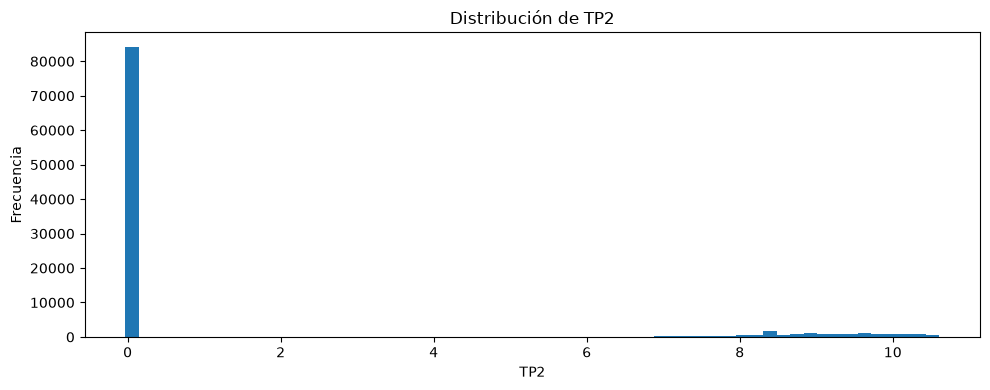

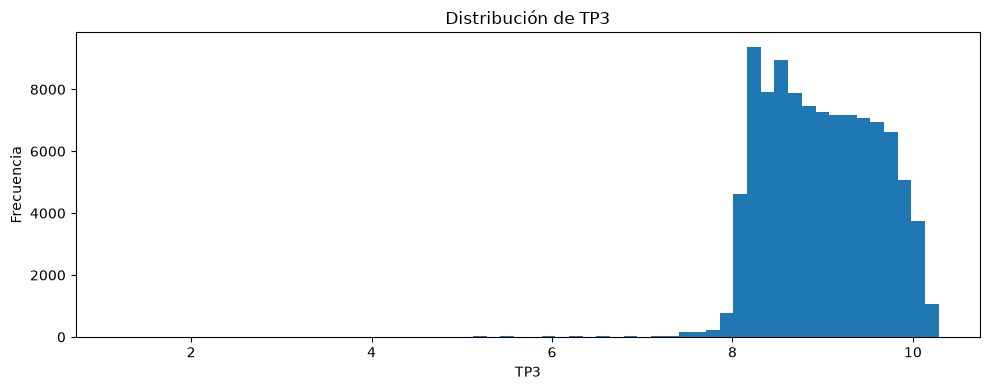

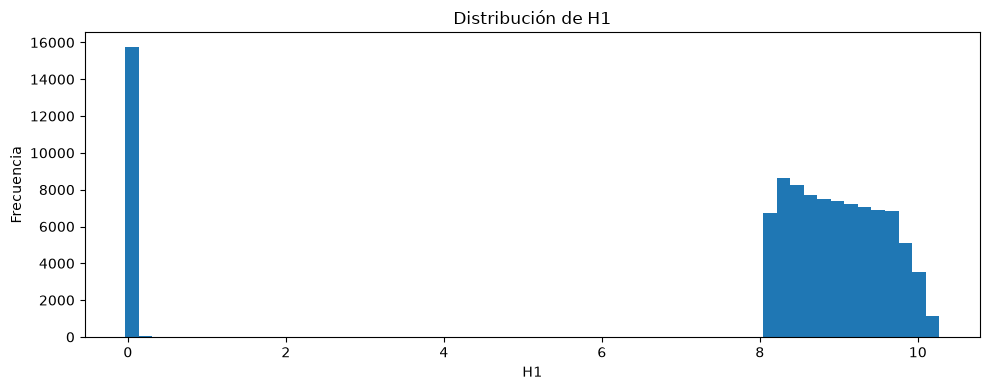

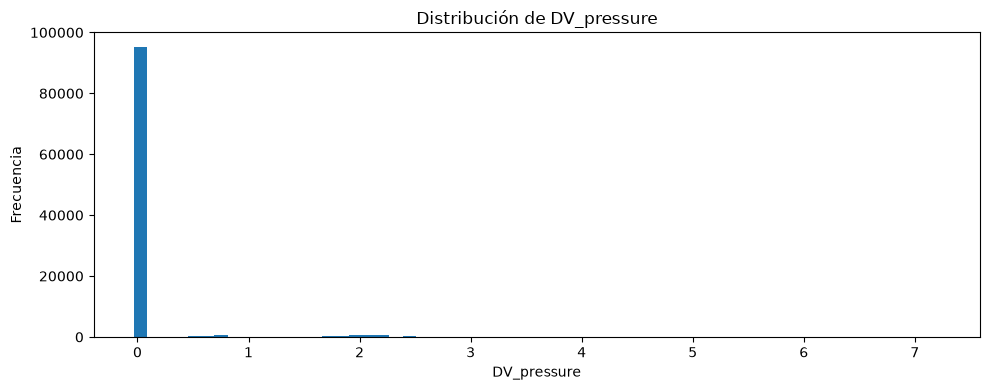

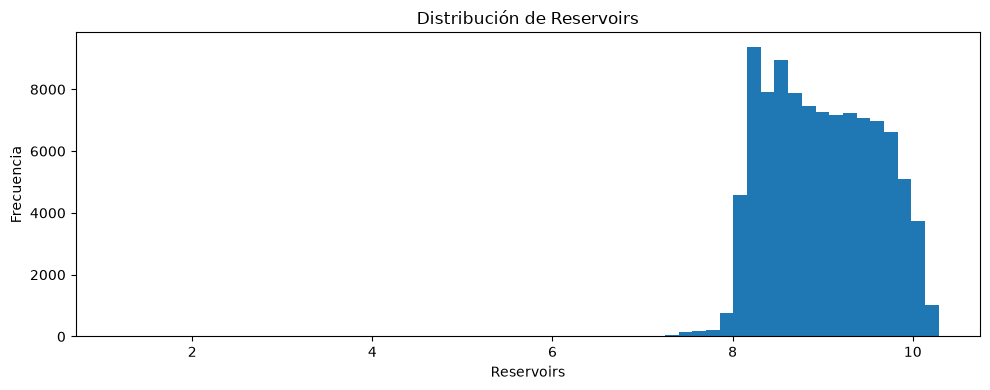

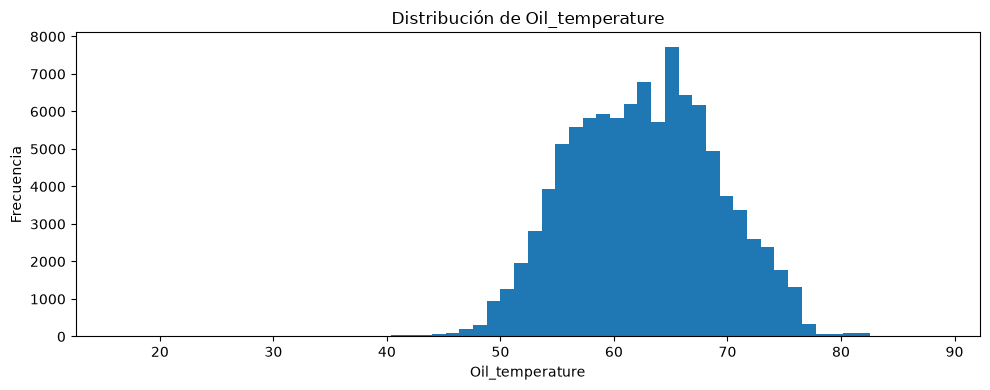

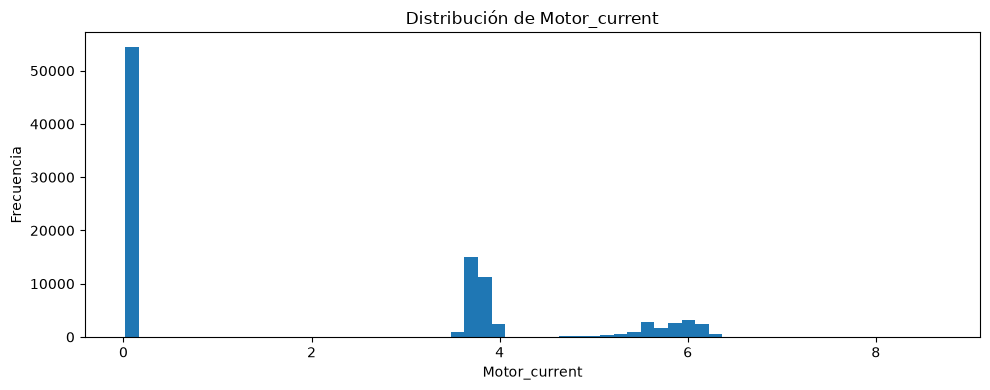

In [66]:
ANALOG_SAMPLE_SIZE = min(100_000, len(df))

analog_sample = df[ANALOG_COLUMNS].sample(
    n=ANALOG_SAMPLE_SIZE,
    random_state=42,
)

import matplotlib.pyplot as plt

for column in ANALOG_COLUMNS:
    plt.figure(figsize=(10, 4))
    plt.hist(
        analog_sample[column],
        bins=60,
    )
    plt.title(f"Distribución de {column}")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# 10. Relación entre variables analógicas

En esta sección se estudia la relación entre los sensores analógicos para identificar variables altamente correlacionadas o posibles mediciones redundantes.

Una correlación elevada no implica que una variable deba eliminarse automáticamente. Puede deberse a que dos sensores miden partes relacionadas del mismo sistema físico.

In [67]:
# Matriz de correlación

analog_correlation = df[ANALOG_COLUMNS].corr()

analog_correlation.round(4)

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current
TP2,1.0000,-0.0112,-0.9613,0.4150,-0.0124,0.2507,0.6975
TP3,-0.0112,1.0000,0.2249,-0.1531,1.0000,0.4016,0.4138
H1,-0.9613,0.2249,1.0000,-0.4255,0.2260,-0.1618,-0.6002
DV_pressure,0.4150,-0.1531,-0.4255,1.0000,-0.1531,0.3397,0.3022
Reservoirs,-0.0124,1.0000,0.2260,-0.1531,1.0000,0.4016,0.4127
Oil_temperature,0.2507,0.4016,-0.1618,0.3397,0.4016,1.0000,0.5287
Motor_current,0.6975,0.4138,-0.6002,0.3022,0.4127,0.5287,1.0000


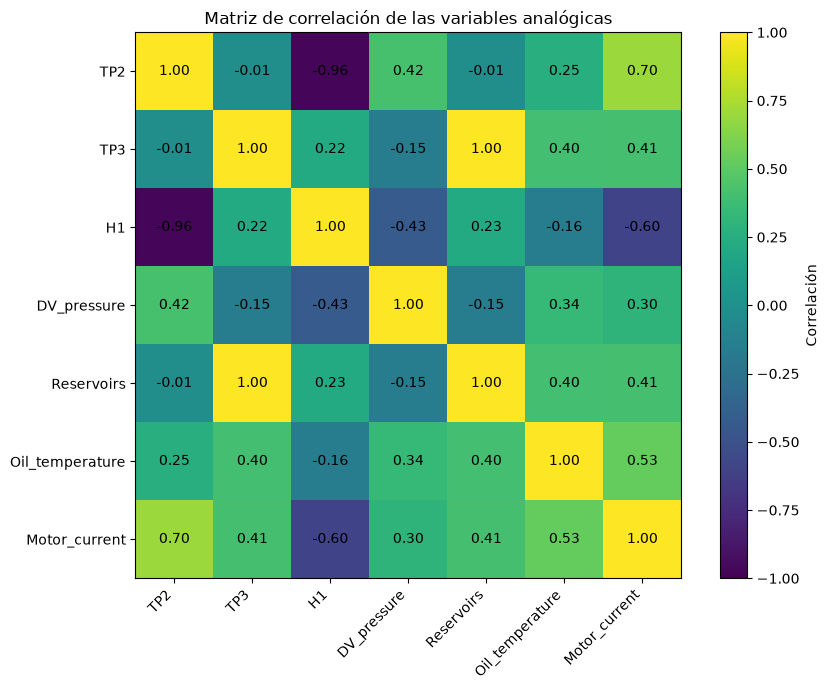

In [68]:
# Representación gráfica

plt.figure(figsize=(9, 7))

correlation_image = plt.imshow(
    analog_correlation,
    vmin=-1,
    vmax=1,
)

plt.xticks(
    range(len(ANALOG_COLUMNS)),
    ANALOG_COLUMNS,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(ANALOG_COLUMNS)),
    ANALOG_COLUMNS,
)

plt.colorbar(correlation_image, label="Correlación")

for row in range(len(ANALOG_COLUMNS)):
    for column in range(len(ANALOG_COLUMNS)):
        plt.text(
            column,
            row,
            f"{analog_correlation.iloc[row, column]:.2f}",
            ha="center",
            va="center",
        )

plt.title("Matriz de correlación de las variables analógicas")
plt.tight_layout()
plt.show()

In [69]:
# Relación entre TP3 y Reservoirs

tp3_reservoirs_difference = (
    df["TP3"] - df["Reservoirs"]
).abs()

tp3_reservoirs_report = pd.DataFrame(
    {
        "Métrica": [
            "Diferencia media absoluta",
            "Diferencia mediana absoluta",
            "Percentil 95",
            "Percentil 99",
            "Diferencia máxima",
            "Registros exactamente iguales (%)",
        ],
        "Resultado": [
            tp3_reservoirs_difference.mean(),
            tp3_reservoirs_difference.median(),
            tp3_reservoirs_difference.quantile(0.95),
            tp3_reservoirs_difference.quantile(0.99),
            tp3_reservoirs_difference.max(),
            (
                tp3_reservoirs_difference.eq(0)
                .mean()
                * 100
            ),
        ],
    }
)

tp3_reservoirs_report

,Métrica,Resultado
0,Diferencia media absoluta,0.001862
1,Diferencia mediana absoluta,0.002000
2,Percentil 95,0.004000
3,Percentil 99,0.006000
4,Diferencia máxima,0.182000
5,Registros exactamente iguales (%),33.158289


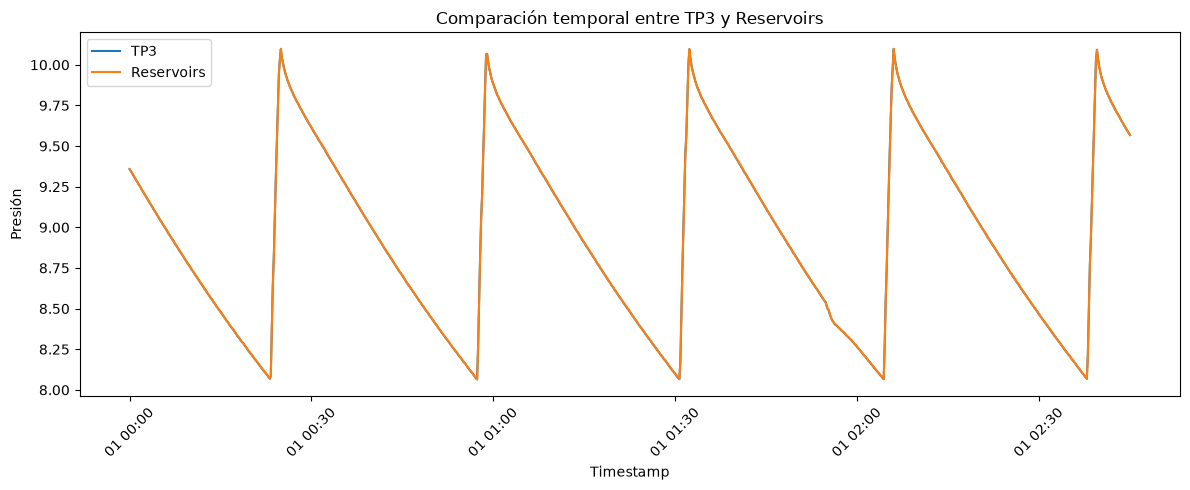

In [71]:
# Visualización comparativa

comparison_sample = df.loc[
    :999,
    ["timestamp", "TP3", "Reservoirs"],
]

plt.figure(figsize=(12, 5))

plt.plot(
    comparison_sample["timestamp"],
    comparison_sample["TP3"],
    label="TP3",
)

plt.plot(
    comparison_sample["timestamp"],
    comparison_sample["Reservoirs"],
    label="Reservoirs",
)

plt.title("Comparación temporal entre TP3 y Reservoirs")
plt.xlabel("Timestamp")
plt.ylabel("Presión")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análisis específico de `TP3` y `Reservoirs`

Las variables `TP3` y `Reservoirs` presentan una correlación prácticamente perfecta y diferencias generalmente muy reducidas.

La diferencia media absoluta entre ambas señales es de `0,001862`, mientras que el 99 % de las observaciones presenta una diferencia inferior o igual a `0,006`. No obstante, solamente el 33,16 % de los registros son exactamente iguales y la diferencia máxima alcanza `0,182`.

Por tanto, ambas variables contienen información muy similar, pero no pueden considerarse duplicadas. Se conservarán durante las siguientes fases del proyecto para comprobar si sus diferencias aportan información útil durante transiciones operativas o intervalos próximos a averías.

# 11. Evaluación de la columna `Unnamed: 0`

En esta sección se analiza la columna `Unnamed: 0` para determinar si representa una variable útil del proceso o un índice auxiliar generado durante la preparación o exportación del dataset.

Se comprobarán su unicidad, orden, incrementos y relación con el tiempo transcurrido desde el inicio de la serie.

In [73]:
# Propiedades generales

index_column_report = pd.DataFrame(
    {
        "Métrica": [
            "Tipo de dato",
            "Valores únicos",
            "Valores duplicados",
            "Orden ascendente",
            "Valor mínimo",
            "Valor máximo",
        ],
        "Resultado": [
            str(df["Unnamed: 0"].dtype),
            df["Unnamed: 0"].nunique(),
            int(df["Unnamed: 0"].duplicated().sum()),
            df["Unnamed: 0"].is_monotonic_increasing,
            df["Unnamed: 0"].min(),
            df["Unnamed: 0"].max(),
        ],
    }
)

index_column_report

,Métrica,Resultado
0,Tipo de dato,int64
1,Valores únicos,1516948
2,Valores duplicados,0
3,Orden ascendente,True
4,Valor mínimo,0
5,Valor máximo,15169470


In [74]:
# Incrementos entre registros

index_differences = df["Unnamed: 0"].diff().dropna()

index_difference_report = (
    index_differences
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("Incremento")
    .reset_index(name="Porcentaje")
    .head(15)
)

index_difference_report

,Incremento,Porcentaje
0,10.0,100.0


In [75]:
# Relación con el tiempo transcurrido

elapsed_seconds = (
    df["timestamp"] - df["timestamp"].min()
).dt.total_seconds()

index_time_difference = df["Unnamed: 0"] - elapsed_seconds

index_time_report = pd.DataFrame(
    {
        "Métrica": [
            "Correlación con el tiempo transcurrido",
            "Diferencia media",
            "Diferencia mediana",
            "Diferencia mínima",
            "Diferencia máxima",
        ],
        "Resultado": [
            df["Unnamed: 0"].corr(elapsed_seconds),
            index_time_difference.mean(),
            index_time_difference.median(),
            index_time_difference.min(),
            index_time_difference.max(),
        ],
    }
)

index_time_report

,Métrica,Resultado
0,Correlación con el tiempo transcurrido,9.999090e-01
1,Diferencia media,-1.569982e+06
2,Diferencia mediana,-1.602932e+06
3,Diferencia mínima,-3.248164e+06
4,Diferencia máxima,4.100000e+02


In [77]:
# Inspección de algunos registros

pd.DataFrame(
    {
        "Unnamed: 0": df["Unnamed: 0"].head(20),
        "timestamp": df["timestamp"].head(20),
        "Segundos transcurridos": elapsed_seconds.head(20),
        "Diferencia": index_time_difference.head(20),
    }
    )

,Unnamed: 0,timestamp,Segundos transcurridos,Diferencia
0,0,2020-02-01 00:00:00,0.0,0.0
1,10,2020-02-01 00:00:10,10.0,0.0
2,20,2020-02-01 00:00:19,19.0,1.0
3,30,2020-02-01 00:00:29,29.0,1.0
4,40,2020-02-01 00:00:39,39.0,1.0
5,50,2020-02-01 00:00:49,49.0,1.0
6,60,2020-02-01 00:00:59,59.0,1.0
7,70,2020-02-01 00:01:09,69.0,1.0
8,80,2020-02-01 00:01:19,79.0,1.0
9,90,2020-02-01 00:01:29,89.0,1.0


## Interpretación

La columna `Unnamed: 0` comienza en cero y aumenta exactamente en 10 unidades en cada registro. Su comportamiento corresponde a una secuencia determinista asociada a la posición de las filas y no a una medición física del compresor.

Aunque presenta una correlación muy elevada con el tiempo transcurrido (`0,999909`), esta relación se debe a que ambas variables aumentan de forma aproximadamente lineal. La diferencia entre ambas crece considerablemente cuando existen interrupciones en la adquisición, ya que `timestamp` conserva los huecos temporales reales, mientras que `Unnamed: 0` continúa avanzando siempre en incrementos constantes de 10.

Por tanto, esta columna no debe utilizarse como sustituto del tiempo real ni para analizar la continuidad temporal. La información cronológica relevante está contenida en `timestamp`.

En consecuencia, `Unnamed: 0` se considera una columna auxiliar redundante y se eliminará durante la fase de transformación del pipeline.

In [78]:
expected_index_values = df.index.to_series() * 10

is_scaled_dataframe_index = (
    df["Unnamed: 0"]
    .eq(expected_index_values)
    .all()
)

is_scaled_dataframe_index

np.True_